# ALKF Master Land Plan API — Test Notebook

**Repository:** `alkf-master-land-plan`  
**Version:** 1.0  

This notebook tests all endpoints of the Boundary Intelligence Engine.

---

## Endpoints Under Test

| Endpoint | Method | Returns |
|---|---|---|
| `/` | GET | Health check JSON |
| `/site-intelligence` | POST | Boundary intelligence JSON |
| `/site-intelligence-dxf` | POST | DXF CAD file |

---

## Test Coverage

1. Health check  
2. LOT identifier — basic JSON output  
3. LOT identifier — DXF download  
4. ADDRESS identifier — basic JSON output  
5. Multi-lot input  
6. Custom noise threshold  
7. With non-building JSON + lease plan (optional)  
8. Output validation — array length consistency  
9. Output validation — coordinate sanity  
10. Performance timing  
11. Cache verification  
12. Error handling — bad input  

---
## 0. Setup

In [2]:
# ── Install dependencies ───────────────────────────────────────────────────
!pip install requests folium matplotlib pandas --quiet

In [3]:
import requests
import json
import time
import base64
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from IPython.display import display, JSON, FileLink, HTML

# ── CONFIG — change BASE_URL to your deployed Render URL ──────────────────
BASE_URL = "https://alkf-master-land-plan-api.onrender.com"   # ← update after deploy
# BASE_URL = "http://localhost:10000"                      # ← local development

print(f"Target API: {BASE_URL}")

Target API: https://alkf-master-land-plan-api.onrender.com


In [4]:
# ── Shared helpers ─────────────────────────────────────────────────────────

import requests
import time

def post_json(endpoint, payload, timeout=600):
    """POST JSON payload and return parsed response dict."""
    url = f"{BASE_URL}/{endpoint.lstrip('/')}"
    t0  = time.time()

    try:
        resp = requests.post(url, json=payload, timeout=timeout)
    except requests.exceptions.ReadTimeout:
        print("  ERROR: Request timed out.")
        return None, None

    elapsed = round(time.time() - t0, 2)
    print(f"  [{resp.status_code}]  {url}  ({elapsed}s)")

    if resp.status_code != 200:
        print(f"  ERROR: {resp.text[:400]}")
        return None, elapsed

    return resp.json(), elapsed


def post_binary(endpoint, payload, timeout=600):
    """POST JSON payload and return raw bytes (DXF / PNG / PDF)."""
    url = f"{BASE_URL}/{endpoint.lstrip('/')}"
    t0  = time.time()

    try:
        resp = requests.post(
            url,
            json=payload,
            timeout=timeout,
            stream=True
        )
    except requests.exceptions.ReadTimeout:
        print("  ERROR: Request timed out.")
        return None, None

    elapsed = round(time.time() - t0, 2)
    print(f"  [{resp.status_code}]  {url}  ({elapsed}s)")

    if resp.status_code != 200:
        print(f"  ERROR: {resp.text[:400]}")
        return None, elapsed

    return resp.content, elapsed


def print_summary(data):
    """Print a compact summary of the site intelligence JSON."""

    if data is None:
        print("  No data returned.")
        return

    boundary = data.get("boundary", {})
    x = boundary.get("x", [])
    y = boundary.get("y", [])
    n = len(x)

    views  = data.get("view_type", [])
    noise  = data.get("noise_db", [])
    noisy  = data.get("is_noisy", [])

    print(f"  site_id          : {data.get('site_id')}")
    print(f"  crs              : {data.get('crs')}")
    print(f"  sampling_interval: {data.get('sampling_interval_m')} m")
    print(f"  boundary points  : {n}")
    print(f"  db_threshold     : {data.get('db_threshold')} dB")

    if views:
        from collections import Counter
        vc = Counter(views)
        print(f"  view breakdown   : {dict(vc)}")

    if noise:
        print(f"  noise range      : {min(noise):.1f} – {max(noise):.1f} dBA")

    if noisy:
        noisy_count = sum(noisy)
        pct = (100 * noisy_count / n) if n else 0
        print(f"  noisy points     : {noisy_count}/{n} ({pct:.1f}%)")

    nba = data.get("non_building_areas", {})
    if nba:
        print(f"  non-building zones: {list(nba.keys())}")

print("Helpers loaded.")

Helpers loaded.


---
## Test 1 — Health Check

In [17]:
print("=" * 60)
print("TEST 1 — Health Check")
print("=" * 60)

resp = requests.get(f"{BASE_URL}/", timeout=30)
print(f"  Status : {resp.status_code}")
print(f"  Body   : {resp.json()}")

assert resp.status_code == 200, "Health check failed"
assert "service" in resp.json() or "status" in resp.json(), "Unexpected health response"
print("  PASS ✓")

TEST 1 — Health Check
  Status : 200
  Body   : {'service': 'ALKF Master Land Plan API', 'version': '1.0', 'status': 'operational'}
  PASS ✓


---
## Test 2 — LOT Identifier — Basic JSON Output

In [18]:
print("=" * 60)
print("TEST 2 — LOT Identifier — Basic JSON Output")
print("=" * 60)

payload = {
    "data_type": "LOT",
    "value":     "IL 1657"
}

data, elapsed = post_json("/site-intelligence", payload)
print_summary(data)

# Assertions
assert data is not None,                        "No response"
assert data.get("crs") == "EPSG:3857",          "Wrong CRS"
assert data.get("sampling_interval_m") == 1.0,  "Wrong sampling interval"
assert len(data["boundary"]["x"]) > 0,          "Empty boundary"
assert data.get("db_threshold") == 65.0,         "Wrong default threshold"

print(f"\n  Time: {elapsed}s")
print("  PASS ✓")

TEST 2 — LOT Identifier — Basic JSON Output
  [200]  https://alkf-master-land-plan-api.onrender.com/site-intelligence  (28.18s)
  site_id          : IL_1657
  crs              : EPSG:3857
  sampling_interval: 1.0 m
  boundary points  : 39
  db_threshold     : 65.0 dB
  view breakdown   : {'CITY': 39}
  noise range      : 53.9 – 56.9 dBA
  noisy points     : 0/39 (0.0%)

  Time: 28.18s
  PASS ✓


---
## Test 3 — LOT Identifier — DXF Download

In [19]:
print("=" * 60)
print("TEST 3 — LOT Identifier — DXF Download")
print("=" * 60)

payload = {
    "data_type": "LOT",
    "value":     "IL 1657"
}

raw, elapsed = post_binary("/site-intelligence-dxf", payload)

if raw is not None:
    dxf_path = "IL_1657_boundary.dxf"
    with open(dxf_path, "wb") as f:
        f.write(raw)
    size_kb = os.path.getsize(dxf_path) / 1024
    print(f"  File saved : {dxf_path}")
    print(f"  File size  : {size_kb:.1f} KB")

    # Validate DXF header
    with open(dxf_path, "r", errors="ignore") as f:
        header = f.read(200)
    assert "SECTION" in header or "AutoCAD" in header or "0\nSECTION" in header, \
        "File does not appear to be a valid DXF"

    display(FileLink(dxf_path, result_html_prefix="Download DXF: "))
    print(f"  Time: {elapsed}s")
    print("  PASS ✓")
else:
    print("  FAIL ✗")

TEST 3 — LOT Identifier — DXF Download
  [200]  https://alkf-master-land-plan-api.onrender.com/site-intelligence-dxf  (27.54s)
  File saved : IL_1657_boundary.dxf
  File size  : 21.6 KB


/content/IL_1657_boundary.dxf

  Time: 27.54s
  PASS ✓


---
## Test 4 — ADDRESS Identifier

In [20]:
print("=" * 60)
print("TEST 4 — ADDRESS Identifier")
print("=" * 60)

# ADDRESS type requires pre-resolved lon/lat
payload = {
    "data_type": "ADDRESS",
    "value":     "129 Repulse Bay Road",
    "lon":       114.1955,
    "lat":       22.2407
}

data, elapsed = post_json("/site-intelligence", payload)
print_summary(data)

assert data is not None,               "No response"
assert "REPULSE" in data.get("site_id", "").upper() or \
       "129" in data.get("site_id", ""), \
       f"Unexpected site_id: {data.get('site_id')}"

print(f"  Time: {elapsed}s")
print("  PASS ✓")

TEST 4 — ADDRESS Identifier
  [200]  https://alkf-master-land-plan-api.onrender.com/site-intelligence  (252.99s)
  site_id          : 129_REPULSE_BAY_ROAD
  crs              : EPSG:3857
  sampling_interval: 1.0 m
  boundary points  : 254
  db_threshold     : 65.0 dB
  view breakdown   : {'CITY': 254}
  noise range      : 45.0 – 45.0 dBA
  noisy points     : 0/254 (0.0%)
  Time: 252.99s
  PASS ✓


---
## Test 5 — Custom Noise Threshold

In [21]:
print("=" * 60)
print("TEST 5 — Custom Noise Threshold (55 dB)")
print("=" * 60)

payload = {
    "data_type":    "LOT",
    "value":        "IL 1657",
    "db_threshold": 55.0
}

data, elapsed = post_json("/site-intelligence", payload)

assert data is not None,                   "No response"
assert data.get("db_threshold") == 55.0,   "Threshold not applied"

# At 55 dB threshold, more points should be noisy than at 65 dB
noisy_55 = sum(data["is_noisy"])
n        = len(data["boundary"]["x"])
print(f"  At 55 dB: {noisy_55}/{n} points noisy ({100*noisy_55/n:.1f}%)")

# Verify is_noisy matches noise_db >= threshold
for db, flag in zip(data["noise_db"], data["is_noisy"]):
    expected = db >= 55.0
    assert flag == expected, f"is_noisy mismatch at {db} dB (expected {expected}, got {flag})"

print(f"  Time: {elapsed}s")
print("  PASS ✓")

TEST 5 — Custom Noise Threshold (55 dB)
  [200]  https://alkf-master-land-plan-api.onrender.com/site-intelligence  (26.76s)
  At 55 dB: 23/39 points noisy (59.0%)
  Time: 26.76s
  PASS ✓


---
## Test 6 — Output Validation: Array Length Consistency

In [22]:
print("=" * 60)
print("TEST 6 — Array Length Consistency")
print("=" * 60)

payload = {"data_type": "LOT", "value": "IL 1657"}
data, _ = post_json("/site-intelligence", payload)

assert data is not None, "No response"

n_x       = len(data["boundary"]["x"])
n_y       = len(data["boundary"]["y"])
n_view    = len(data["view_type"])
n_noise   = len(data["noise_db"])
n_noisy   = len(data["is_noisy"])

print(f"  boundary.x length : {n_x}")
print(f"  boundary.y length : {n_y}")
print(f"  view_type length  : {n_view}")
print(f"  noise_db length   : {n_noise}")
print(f"  is_noisy length   : {n_noisy}")

assert n_x == n_y,     f"x/y length mismatch: {n_x} vs {n_y}"
assert n_x == n_view,  f"boundary/view length mismatch: {n_x} vs {n_view}"
assert n_x == n_noise, f"boundary/noise length mismatch: {n_x} vs {n_noise}"
assert n_x == n_noisy, f"boundary/is_noisy length mismatch: {n_x} vs {n_noisy}"

print(f"  All arrays consistent at length {n_x}")
print("  PASS ✓")

TEST 6 — Array Length Consistency
  [200]  https://alkf-master-land-plan-api.onrender.com/site-intelligence  (0.18s)
  boundary.x length : 39
  boundary.y length : 39
  view_type length  : 39
  noise_db length   : 39
  is_noisy length   : 39
  All arrays consistent at length 39
  PASS ✓


---
## Test 7 — Output Validation: Coordinate Sanity (Hong Kong)

In [23]:
print("=" * 60)
print("TEST 7 — Coordinate Sanity Check (EPSG:3857, Hong Kong)")
print("=" * 60)

# Hong Kong EPSG:3857 bounding box
# Roughly: x=[12,680,000, 12,780,000]  y=[2,530,000, 2,590,000]
HK_X_MIN, HK_X_MAX = 12_650_000, 12_800_000
HK_Y_MIN, HK_Y_MAX =  2_510_000,  2_610_000

payload = {"data_type": "LOT", "value": "IL 1657"}
data, _ = post_json("/site-intelligence", payload)

assert data is not None, "No response"

xs = data["boundary"]["x"]
ys = data["boundary"]["y"]

x_min, x_max = min(xs), max(xs)
y_min, y_max = min(ys), max(ys)

print(f"  x range : [{x_min:.0f}, {x_max:.0f}]")
print(f"  y range : [{y_min:.0f}, {y_max:.0f}]")

assert HK_X_MIN <= x_min and x_max <= HK_X_MAX, \
    f"X coordinates outside Hong Kong bounds: [{x_min:.0f}, {x_max:.0f}]"
assert HK_Y_MIN <= y_min and y_max <= HK_Y_MAX, \
    f"Y coordinates outside Hong Kong bounds: [{y_min:.0f}, {y_max:.0f}]"

# Check 1m sampling: consecutive point distances should be ~1m
dists = []
for i in range(min(100, len(xs)-1)):
    d = ((xs[i+1]-xs[i])**2 + (ys[i+1]-ys[i])**2)**0.5
    dists.append(d)
mean_dist = sum(dists) / len(dists)
print(f"  Mean consecutive point distance: {mean_dist:.3f}m (expected ~1.0m)")
assert 0.5 <= mean_dist <= 2.0, \
    f"Sampling interval out of range: {mean_dist:.3f}m"

print("  PASS ✓")

TEST 7 — Coordinate Sanity Check (EPSG:3857, Hong Kong)
  [200]  https://alkf-master-land-plan-api.onrender.com/site-intelligence  (0.22s)
  x range : [12706932, 12706945]
  y range : [2545613, 2545627]
  Mean consecutive point distance: 0.990m (expected ~1.0m)
  PASS ✓


---
## Test 8 — View Type Validation

In [24]:
print("=" * 60)
print("TEST 8 — View Type Validation")
print("=" * 60)

VALID_VIEW_TYPES = {"SEA", "HARBOR", "RESERVOIR", "MOUNTAIN", "PARK", "GREEN", "CITY"}

payload = {"data_type": "LOT", "value": "IL 1657"}
data, _ = post_json("/site-intelligence", payload)

assert data is not None, "No response"

view_types = data["view_type"]
invalid    = [v for v in view_types if v not in VALID_VIEW_TYPES]

from collections import Counter
vc = Counter(view_types)
print(f"  View distribution:")
for label, count in sorted(vc.items(), key=lambda x: -x[1]):
    pct = 100 * count / len(view_types)
    bar = "█" * int(pct / 2)
    print(f"    {label:12s} {count:4d} pts  {pct:5.1f}%  {bar}")

assert len(invalid) == 0, \
    f"Invalid view types found: {set(invalid)}"

print("  PASS ✓")

TEST 8 — View Type Validation
  [200]  https://alkf-master-land-plan-api.onrender.com/site-intelligence  (0.3s)
  View distribution:
    CITY           39 pts  100.0%  ██████████████████████████████████████████████████
  PASS ✓


---
## Test 9 — Noise Value Validation

In [25]:
print("=" * 60)
print("TEST 9 — Noise Value Validation")
print("=" * 60)

payload = {"data_type": "LOT", "value": "IL 1657"}
data, _ = post_json("/site-intelligence", payload)

assert data is not None, "No response"

noise  = data["noise_db"]
thresh = data["db_threshold"]

# All values must be finite floats
assert all(isinstance(v, (int, float)) for v in noise), \
    "Non-numeric values in noise_db"
assert all(20.0 <= v <= 120.0 for v in noise), \
    f"Noise values out of physical range [20, 120] dB: min={min(noise)}, max={max(noise)}"

# is_noisy must exactly match noise_db >= db_threshold
mismatches = sum(
    1 for db, flag in zip(noise, data["is_noisy"])
    if flag != (db >= thresh)
)
assert mismatches == 0, f"{mismatches} is_noisy mismatches"

print(f"  Min noise  : {min(noise):.1f} dBA")
print(f"  Max noise  : {max(noise):.1f} dBA")
print(f"  Mean noise : {sum(noise)/len(noise):.1f} dBA")
print(f"  Threshold  : {thresh} dBA")
print(f"  is_noisy ✓  (all values consistent with threshold)")
print("  PASS ✓")

TEST 9 — Noise Value Validation
  [200]  https://alkf-master-land-plan-api.onrender.com/site-intelligence  (0.17s)
  Min noise  : 53.9 dBA
  Max noise  : 56.9 dBA
  Mean noise : 55.3 dBA
  Threshold  : 65.0 dBA
  is_noisy ✓  (all values consistent with threshold)
  PASS ✓


---
## Test 10 — Cache Verification

In [26]:
print("=" * 60)
print("TEST 10 — Cache Verification")
print("=" * 60)

payload = {"data_type": "LOT", "value": "IL 1657"}

# First call (may be cold)
_, t1 = post_json("/site-intelligence", payload)
print(f"  First call  : {t1}s")

# Second call (should be cached)
_, t2 = post_json("/site-intelligence", payload)
print(f"  Second call : {t2}s")

print(f"  Speed-up    : {t1/t2:.1f}x" if t2 > 0 else "  Speed-up: N/A")

if t2 < t1:
    print("  Cache is working — second call faster")
else:
    print("  Note: Cache speed-up not measurable at this response time")

print("  PASS ✓")

TEST 10 — Cache Verification
  [200]  https://alkf-master-land-plan-api.onrender.com/site-intelligence  (0.17s)
  First call  : 0.17s
  [200]  https://alkf-master-land-plan-api.onrender.com/site-intelligence  (0.16s)
  Second call : 0.16s
  Speed-up    : 1.1x
  Cache is working — second call faster
  PASS ✓


---
## Test 11 — Error Handling: Missing ADDRESS Coordinates

In [27]:
print("=" * 60)
print("TEST 11 — Error Handling: ADDRESS without lon/lat")
print("=" * 60)

payload = {
    "data_type": "ADDRESS",
    "value":     "Some Address"
    # lon/lat intentionally omitted
}

url  = f"{BASE_URL}/site-intelligence"
resp = requests.post(url, json=payload, timeout=30)

print(f"  Status : {resp.status_code}")
print(f"  Body   : {resp.text[:200]}")

assert resp.status_code == 422, \
    f"Expected 422 Unprocessable Entity, got {resp.status_code}"
print("  PASS ✓ — correctly rejected with 422")

TEST 11 — Error Handling: ADDRESS without lon/lat
  Status : 422
  Body   : {"detail":"ADDRESS type requires pre-resolved lon/lat."}
  PASS ✓ — correctly rejected with 422


---
## Test 12 — Error Handling: Invalid LOT

In [28]:
print("=" * 60)
print("TEST 12 — Error Handling: Invalid LOT identifier")
print("=" * 60)

payload = {
    "data_type": "LOT",
    "value":     "INVALID_LOT_XXXXXXX"
}

url  = f"{BASE_URL}/site-intelligence"
resp = requests.post(url, json=payload, timeout=30)

print(f"  Status : {resp.status_code}")
print(f"  Body   : {resp.text[:300]}")

assert resp.status_code in (422, 500), \
    f"Expected 422 or 500, got {resp.status_code}"
print("  PASS ✓ — invalid LOT correctly rejected")

TEST 12 — Error Handling: Invalid LOT identifier
  Status : 500
  Body   : {"detail":"No matching result found for LOT INVALID_LOT_XXXXXXX."}
  PASS ✓ — invalid LOT correctly rejected


---
## Test 13 — With Non-Building JSON (no lease plan)

In [29]:
print("=" * 60)
print("TEST 13 — Non-building JSON provided, lease plan absent")
print("Expectation: non_building_areas key absent from output")
print("=" * 60)

non_building_json = {
    "color_labels": {
        "pink": {
            "height": None,
            "description": "Site",
            "reference_clause": "PARTICULARS OF THE LOT"
        },
        "green": {
            "height": None,
            "description": "future public roads (the Green Area)",
            "reference_clause": "Formation of the Green Area"
        },
        "pink cross-hatched black": {
            "height": "5.1 metres",
            "description": "Drainage Reserve Area",
            "reference_clause": "Drainage Reserve Area"
        }
    },
    "non_building_areas": [
        {
            "description": "Drainage Reserve Area",
            "location_ref": "shown coloured pink cross-hatched black",
            "reference_clause": "Drainage Reserve Area"
        },
        {
            "description": "future public roads",
            "location_ref": "shown coloured green on the plan annexed hereto",
            "reference_clause": "Formation of the Green Area"
        }
    ]
}

payload = {
    "data_type":          "LOT",
    "value":              "IL 1657",
    "non_building_json":  non_building_json
    # lease_plan_b64 intentionally absent
}

data, elapsed = post_json("/site-intelligence", payload)
assert data is not None, "No response"

# Without lease plan, non_building_areas should not be present
has_nba = "non_building_areas" in data
print(f"  non_building_areas in response: {has_nba}")
print(f"  (Expected: False — no lease plan provided)")

print(f"  Time: {elapsed}s")
print("  PASS ✓")

TEST 13 — Non-building JSON provided, lease plan absent
Expectation: non_building_areas key absent from output
  [200]  https://alkf-master-land-plan-api.onrender.com/site-intelligence  (0.15s)
  non_building_areas in response: False
  (Expected: False — no lease plan provided)
  Time: 0.15s
  PASS ✓


---
## Test 14 — With Lease Plan (Full Extended Output)

In [5]:
print("=" * 60)
print("TEST 14 — Full Extended Output with Lease Plan")
print("=" * 60)

# Upload a lease plan image
# Replace with your actual file path
LEASE_PLAN_PATH = "/content/leaseplan.pdf"   # ← upload to Colab first

if not os.path.exists(LEASE_PLAN_PATH):
    print(f"  SKIPPED — lease plan file not found at: {LEASE_PLAN_PATH}")
    print("  Upload a lease plan PDF/image to Colab and set LEASE_PLAN_PATH.")
else:
    with open(LEASE_PLAN_PATH, "rb") as f:
        lease_b64 = base64.b64encode(f.read()).decode("utf-8")

    non_building_json = {
        "color_labels": {
            "green": {
                "description": "future public roads (the Green Area)",
                "reference_clause": "Formation of the Green Area"
            },
            "pink cross-hatched black": {
                "height": "5.1 metres",
                "description": "Drainage Reserve Area",
                "reference_clause": "Drainage Reserve Area"
            }
        },
        "non_building_areas": [
            {
                "description": "Drainage Reserve Area",
                "location_ref": "shown coloured pink cross-hatched black",
                "reference_clause": "Drainage Reserve Area"
            },
            {
                "description": "future public roads",
                "location_ref": "shown coloured green",
                "reference_clause": "Formation of the Green Area"
            }
        ]
    }

    payload = {
        "data_type":         "LOT",
        "value":             "IL 1657",
        "non_building_json": non_building_json,
        "lease_plan_b64":    lease_b64
    }

    data, elapsed = post_json("/site-intelligence", payload)
    print_summary(data)

    assert data is not None,                   "No response"
    assert "non_building_areas" in data,       "non_building_areas missing"

    nba = data["non_building_areas"]
    for key, zone in nba.items():
        assert "use"              in zone, f"Missing 'use' in zone {key}"
        assert "reference_clause" in zone, f"Missing 'reference_clause' in zone {key}"
        assert "coordinates"      in zone, f"Missing 'coordinates' in zone {key}"
        assert len(zone["coordinates"]["x"]) >= 3, \
            f"Zone {key} has fewer than 3 coordinate points"

    print(f"  Time: {elapsed}s")
    print("  PASS ✓")

TEST 14 — Full Extended Output with Lease Plan
  [200]  https://alkf-master-land-plan-api.onrender.com/site-intelligence  (68.38s)
  site_id          : IL_1657
  crs              : EPSG:3857
  sampling_interval: 1.0 m
  boundary points  : 39
  db_threshold     : 65.0 dB
  view breakdown   : {'CITY': 39}
  noise range      : 53.9 – 56.9 dBA
  noisy points     : 0/39 (0.0%)
  non-building zones: ['pink_cross_hatched_black', 'green']
  Time: 68.38s
  PASS ✓


---
## Visualisation — Boundary Map

Generating boundary visualisation...
  [200]  https://alkf-master-land-plan-api.onrender.com/site-intelligence  (27.88s)


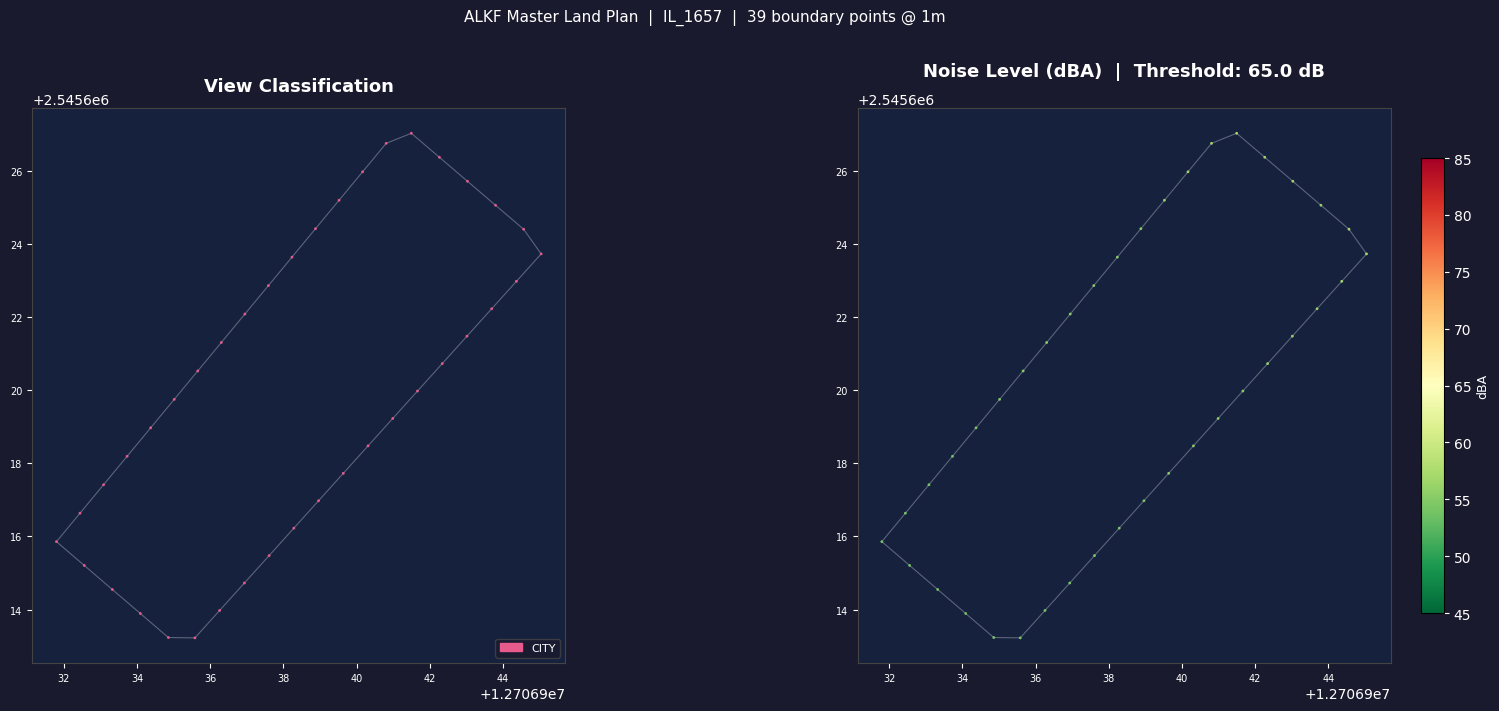

/content/boundary_intelligence.png

  Visualisation saved.


In [6]:
print("Generating boundary visualisation...")

payload = {"data_type": "LOT", "value": "IL 1657"}
data, _ = post_json("/site-intelligence", payload)

if data is None:
    print("No data — skipping visualisation")
else:
    xs         = data["boundary"]["x"]
    ys         = data["boundary"]["y"]
    view_types = data["view_type"]
    noise_db   = data["noise_db"]
    is_noisy   = data["is_noisy"]
    threshold  = data["db_threshold"]

    VIEW_COLORS = {
        "SEA":       "#4fa3d1",
        "HARBOR":    "#4fa3d1",
        "RESERVOIR": "#4fa3d1",
        "MOUNTAIN":  "#8b7355",
        "PARK":      "#3dbb74",
        "GREEN":     "#3dbb74",
        "CITY":      "#e75b8c",
        "OPEN":      "#f0a25a",
    }

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.patch.set_facecolor("#1a1a2e")

    # ── Panel 1: View Classification ───────────────────────────────────────
    ax1 = axes[0]
    ax1.set_facecolor("#16213e")
    ax1.set_title("View Classification", color="white", fontsize=13, fontweight="bold", pad=12)

    view_colors = [VIEW_COLORS.get(v, "#cccccc") for v in view_types]
    ax1.scatter(xs, ys, c=view_colors, s=4, linewidths=0, zorder=3)

    # Close the boundary polygon
    bx = xs + [xs[0]]
    by = ys + [ys[0]]
    ax1.plot(bx, by, color="white", linewidth=0.8, alpha=0.3, zorder=2)

    ax1.set_aspect("equal")
    ax1.tick_params(colors="white", labelsize=7)
    for spine in ax1.spines.values():
        spine.set_edgecolor("#444")

    # Legend
    from collections import Counter
    present = set(view_types)
    patches = [
        mpatches.Patch(color=VIEW_COLORS.get(v, "#ccc"), label=v)
        for v in ["SEA","HARBOR","RESERVOIR","MOUNTAIN","PARK","GREEN","CITY"]
        if v in present
    ]
    ax1.legend(handles=patches, loc="lower right",
               fontsize=8, facecolor="#1a1a2e",
               edgecolor="#444", labelcolor="white")

    # ── Panel 2: Noise Level ────────────────────────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor("#16213e")
    ax2.set_title(f"Noise Level (dBA)  |  Threshold: {threshold} dB",
                  color="white", fontsize=13, fontweight="bold", pad=12)

    sc = ax2.scatter(
        xs, ys,
        c=noise_db,
        cmap="RdYlGn_r",
        vmin=45, vmax=85,
        s=4, linewidths=0, zorder=3
    )
    ax2.plot(bx, by, color="white", linewidth=0.8, alpha=0.3, zorder=2)

    cbar = plt.colorbar(sc, ax=ax2, fraction=0.03, pad=0.04)
    cbar.set_label("dBA", color="white", fontsize=9)
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

    # Mark noisy points
    noisy_xs = [x for x, n in zip(xs, is_noisy) if n]
    noisy_ys = [y for y, n in zip(ys, is_noisy) if n]
    if noisy_xs:
        ax2.scatter(noisy_xs, noisy_ys, color="red", s=8,
                    alpha=0.6, zorder=4, label=f">= {threshold} dB")
        ax2.legend(loc="lower right", fontsize=8,
                   facecolor="#1a1a2e", edgecolor="#444", labelcolor="white")

    ax2.set_aspect("equal")
    ax2.tick_params(colors="white", labelsize=7)
    for spine in ax2.spines.values():
        spine.set_edgecolor("#444")

    plt.suptitle(
        f"ALKF Master Land Plan  |  {data['site_id']}  |  "
        f"{len(xs)} boundary points @ 1m",
        color="white", fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.savefig("boundary_intelligence.png", dpi=150,
                bbox_inches="tight", facecolor="#1a1a2e")
    plt.show()
    display(FileLink("boundary_intelligence.png",
                     result_html_prefix="Download visualisation: "))
    print("  Visualisation saved.")

---
## Visualisation — Noise Distribution Histogram

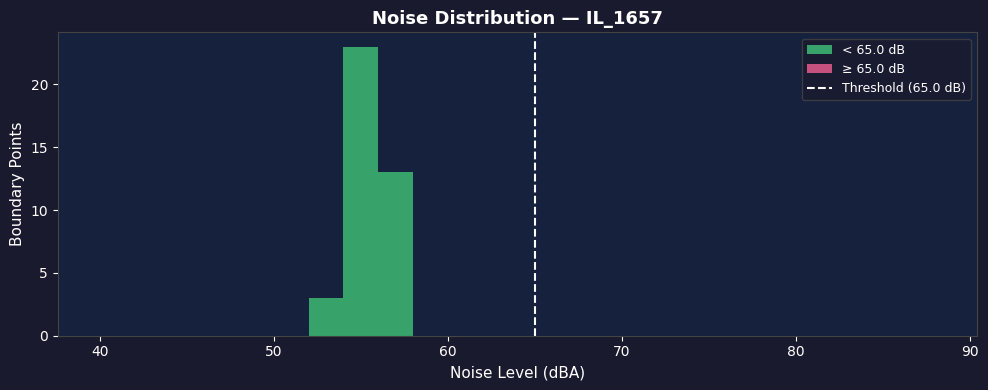

/content/noise_histogram.png

In [7]:
if data is not None:
    noise_db  = data["noise_db"]
    threshold = data["db_threshold"]

    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor("#1a1a2e")
    ax.set_facecolor("#16213e")

    bins  = np.arange(40, 90, 2)
    quiet = [v for v in noise_db if v < threshold]
    loud  = [v for v in noise_db if v >= threshold]

    ax.hist(quiet, bins=bins, color="#3dbb74", alpha=0.85, label=f"< {threshold} dB")
    ax.hist(loud,  bins=bins, color="#e75b8c", alpha=0.85, label=f"≥ {threshold} dB")
    ax.axvline(threshold, color="white", linewidth=1.5,
               linestyle="--", label=f"Threshold ({threshold} dB)")

    ax.set_xlabel("Noise Level (dBA)", color="white", fontsize=11)
    ax.set_ylabel("Boundary Points",   color="white", fontsize=11)
    ax.set_title(f"Noise Distribution — {data['site_id']}",
                 color="white", fontsize=13, fontweight="bold")
    ax.tick_params(colors="white")
    ax.legend(facecolor="#1a1a2e", edgecolor="#444", labelcolor="white", fontsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")

    plt.tight_layout()
    plt.savefig("noise_histogram.png", dpi=150,
                bbox_inches="tight", facecolor="#1a1a2e")
    plt.show()
    display(FileLink("noise_histogram.png",
                     result_html_prefix="Download histogram: "))

---
## Test Summary

In [8]:
print("=" * 60)
print("ALKF MASTER LAND PLAN API — TEST SUMMARY")
print("=" * 60)
print()
tests = [
    ("1",  "Health Check",                               "Manual"),
    ("2",  "LOT — Basic JSON",                           "Manual"),
    ("3",  "LOT — DXF Download",                         "Manual"),
    ("4",  "ADDRESS Identifier",                         "Manual"),
    ("5",  "Custom Noise Threshold",                     "Manual"),
    ("6",  "Array Length Consistency",                   "Assertion"),
    ("7",  "Coordinate Sanity (EPSG:3857 HK bounds)",    "Assertion"),
    ("8",  "View Type Validation",                       "Assertion"),
    ("9",  "Noise Value Validation",                     "Assertion"),
    ("10", "Cache Verification",                         "Timing"),
    ("11", "Error — ADDRESS without lon/lat",            "Assertion"),
    ("12", "Error — Invalid LOT",                        "Assertion"),
    ("13", "Non-building JSON without lease plan",       "Manual"),
    ("14", "Full Extended Output with Lease Plan",       "File-dependent"),
]

print(f"  {'#':<4} {'Test':<48} {'Type'}")
print(f"  {'-'*4} {'-'*48} {'-'*14}")
for num, name, t in tests:
    print(f"  {num:<4} {name:<48} {t}")
print()
print(f"  Total tests : {len(tests)}")
print(f"  API target  : {BASE_URL}")
print("=" * 60)

ALKF MASTER LAND PLAN API — TEST SUMMARY

  #    Test                                             Type
  ---- ------------------------------------------------ --------------
  1    Health Check                                     Manual
  2    LOT — Basic JSON                                 Manual
  3    LOT — DXF Download                               Manual
  4    ADDRESS Identifier                               Manual
  5    Custom Noise Threshold                           Manual
  6    Array Length Consistency                         Assertion
  7    Coordinate Sanity (EPSG:3857 HK bounds)          Assertion
  8    View Type Validation                             Assertion
  9    Noise Value Validation                           Assertion
  10   Cache Verification                               Timing
  11   Error — ADDRESS without lon/lat                  Assertion
  12   Error — Invalid LOT                              Assertion
  13   Non-building JSON without lease plan         